This notebook was used to create molecule depictions in the paper's Figure 3.

In [34]:
from rdkit import Chem
from rdkit.Chem import rdDepictor
from rdkit.Chem import Draw

mol1 = Chem.MolFromSmiles("NC=O")
mol2 = Chem.MolFromSmiles("*C=O")

# 1. Create the template using SMARTS, where '*' means "any atom"
template = Chem.MolFromSmarts("*C=O")

# 2. Compute the 2D coordinates for this wildcard template
rdDepictor.Compute2DCoords(template)

# 3. Align both molecules to the template.
# Because the template uses a wildcard, both will match successfully.
rdDepictor.GenerateDepictionMatching2DStructure(mol1, template)
rdDepictor.GenerateDepictionMatching2DStructure(mol2, template)

((0, 0), (1, 1), (2, 2))

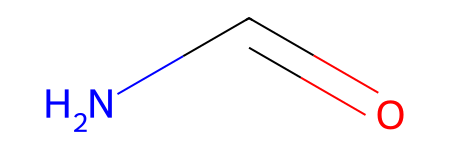

In [35]:
mol1

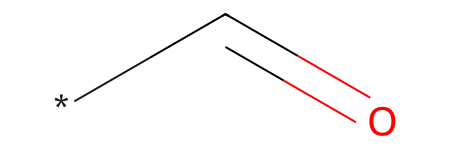

In [36]:
mol2

In [37]:
from rdkit.Chem.Draw import rdMolDraw2D

def save_mol_to_svg(mol, filename):
    # Initialize the SVG drawer with dimensions
    drawer = rdMolDraw2D.MolDraw2DSVG(250, 250)

    # Draw and finalize
    drawer.DrawMolecule(mol)
    drawer.FinishDrawing()

    # Get the SVG text and save it
    svg_text = drawer.GetDrawingText()
    with open(filename, "w") as f:
        f.write(svg_text)

# Save them separately
save_mol_to_svg(mol1, "mol1_aligned.svg")
save_mol_to_svg(mol2, "mol2_aligned.svg")

In [45]:
from rdkit import Chem
from rdkit.Chem import rdDepictor
from rdkit.Chem import Draw

mol1 = Chem.MolFromSmiles("NC=O")
mol2 = Chem.MolFromSmiles("*C=O")

# 1. Create and compute the SMARTS template
template = Chem.MolFromSmarts("*C=O")
rdDepictor.Compute2DCoords(template)

# 2. Align both molecules to the template
rdDepictor.GenerateDepictionMatching2DStructure(mol1, template)
rdDepictor.GenerateDepictionMatching2DStructure(mol2, template)

# 3. Configure custom drawing options
options = Draw.MolDrawOptions()
options.bondLineWidth = 6  # Increase bond thickness (default is usually 2)
options.minFontSize = 80   # Increase font size for atom labels

# 4. Generate individual PIL Images using the custom options
img1 = Draw.MolToImage(mol1, size=(2000, 2000), options=options)
img2 = Draw.MolToImage(mol2, size=(2000, 2000), options=options)

# 5. Save each directly to its own PDF file
img1.save("mol1_aligned.pdf")
img2.save("mol2_aligned.pdf")